In [1]:
%load_ext autoreload
%autoreload 2
import eq
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import copy
import tqdm
import numpy as np
import numpy as np


base_dir = Path(eq.__file__).parent.parent
results_dir = base_dir / 'results' / "AGU25"

In [2]:
!rm -rf /Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/data/ANSS_MultiCatalog
catalog = eq.catalogs.ANSS_MultiCatalog(    
    num_sequences=5000,
    t_end_days=365,
    radius_kilometers=250,
    mag_completeness=4.5,
    minimum_mainshock_mag=6.5,
)

Generating the catalog...
Downloading/loading...


/Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/eq/catalogs/anss.py:173: UserWarning: Using existing /Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/data/raw/anss_global_catalog.csv
  warnings.warn(f"Using existing {filename}")
/Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/eq/catalogs/anss.py:179: UserWarning: 248 NaN values found in catalog. Removing rows with NaN values.
  warnings.warn(


train


100%|██████████| 3000/3000 [00:05<00:00, 587.88it/s]


val


100%|██████████| 1000/1000 [00:01<00:00, 582.76it/s]


test


100%|██████████| 1000/1000 [00:01<00:00, 514.69it/s]


Success!
Catalog saved to /Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/data/ANSS_MultiCatalog


The global anss catalog is a collection of 5000 sequences from the ANSS catalog. We need to train an ETAS model for each sequence. Specifically, the ETAS model is trained on the conditioning period of each sequence (before the t_nll_start).

Here are a few examples of the sequences in the catalog:

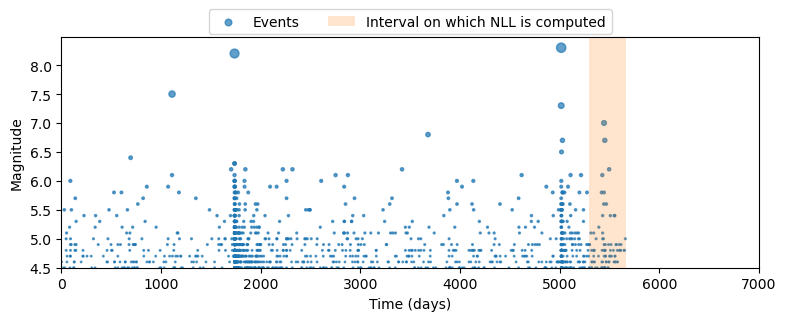

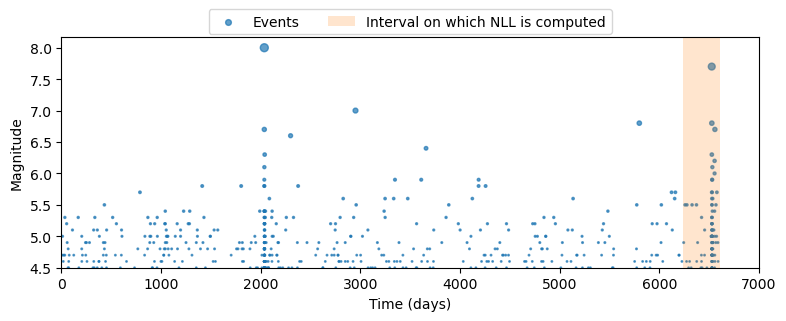

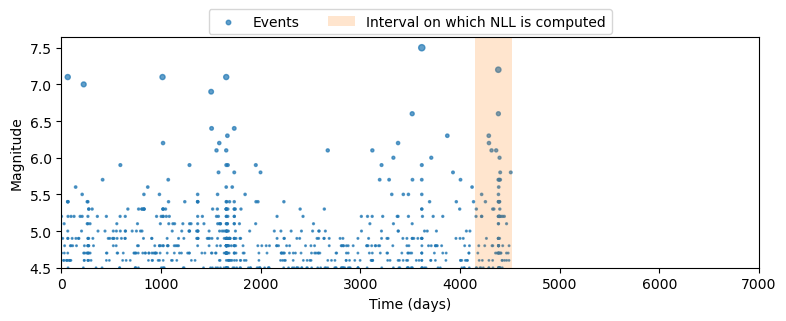

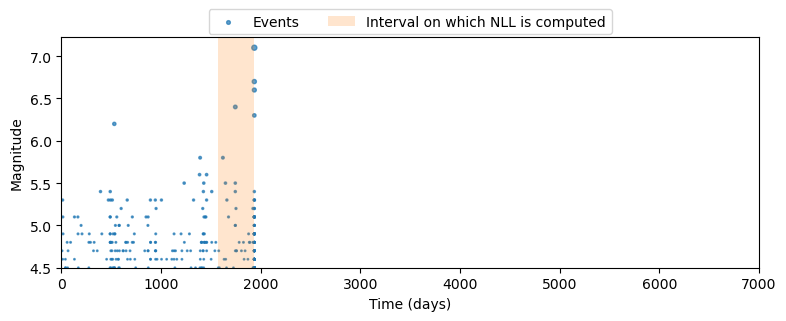

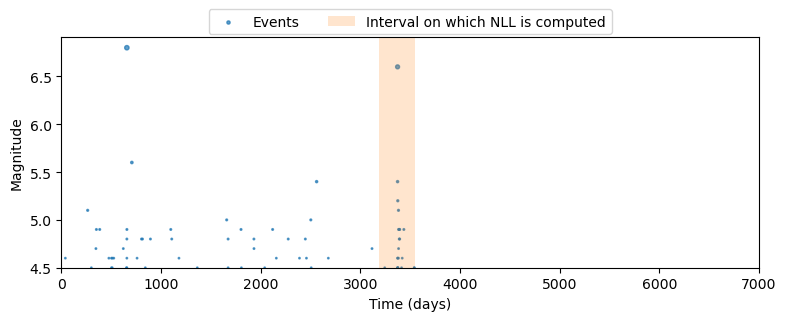

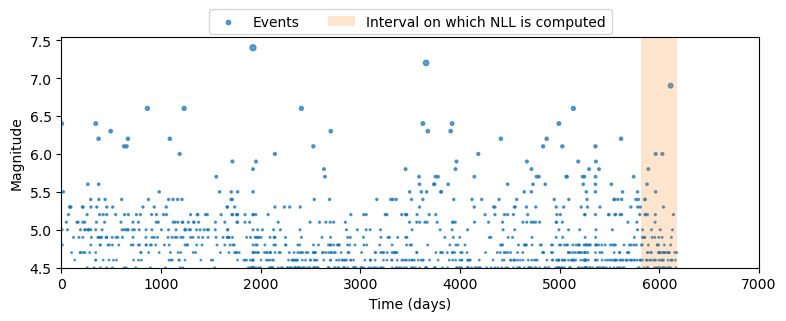

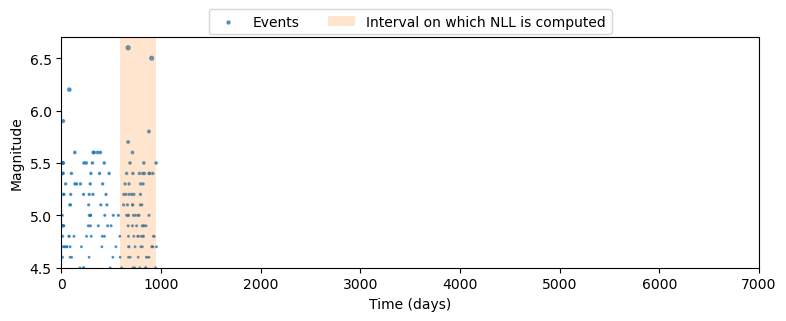

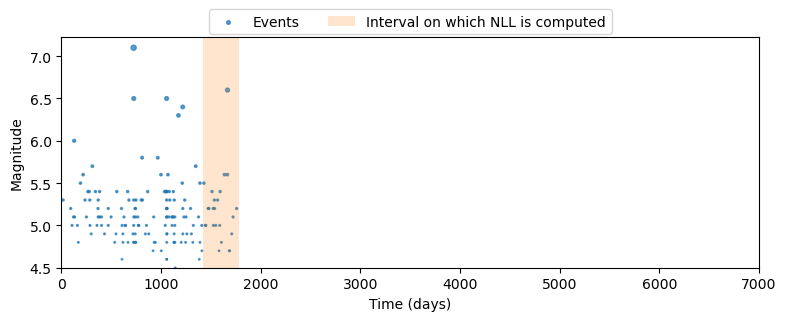

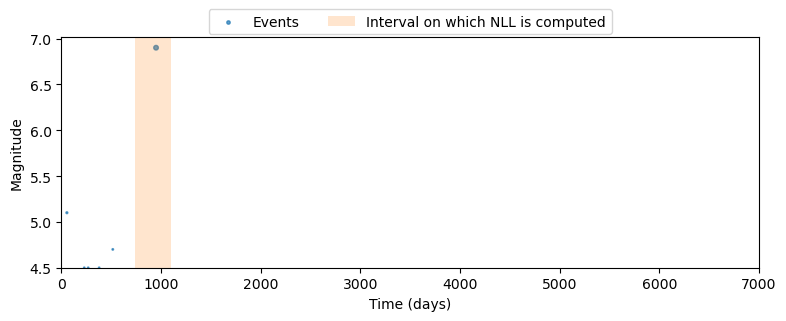

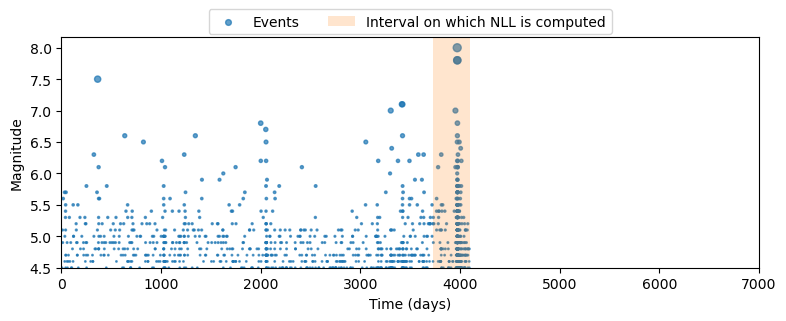

In [3]:
for i in range(10):
    ax = eq.visualization.visualize_sequence(catalog.train[i], show_nll=True)
    ax.set(xlim=(0, 7000))


For now we will use the first sequence in the validation set to test the approach.

<AxesSubplot: xlabel='Time (days)', ylabel='Magnitude'>

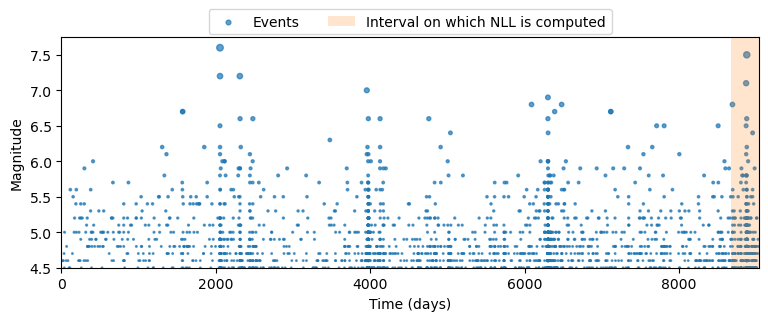

In [53]:
val_index = 50
eq.visualization.visualize_sequence(catalog.val[val_index], show_nll=True)

In [ ]:
seq = copy.deepcopy(catalog.val[val_index])
train_end_time = copy.deepcopy(seq.t_nll_start)
seq.t_nll_start = seq.t_start
train_seq = seq.get_subsequence(0, train_end_time)
train_seq.t_nll_start = 365 # allow for 1 year burn in period 

batch = eq.data.Batch.from_list([train_seq])

model = eq.models.ETAS(
    mag_completeness=catalog.metadata["mag_completeness"],
    base_rate_init=10**torch.mean(torch.log(batch.inter_times))/10, # geometric mean and heuristic guess
)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-1)

number_of_epochs = 1000

train_loss = []
mus = []
alphas = []
cs = []
ps = []
ks = []
for epoch in range(number_of_epochs):
    loss = model.nll_loss(batch)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    train_loss.append(loss.item())
    # Track parameters at each epoch
    mus.append(model.mu.item())
    alphas.append(model.alpha.item())
    cs.append(model.c.item())
    ps.append(model.p.item())
    ks.append(model.k.item())


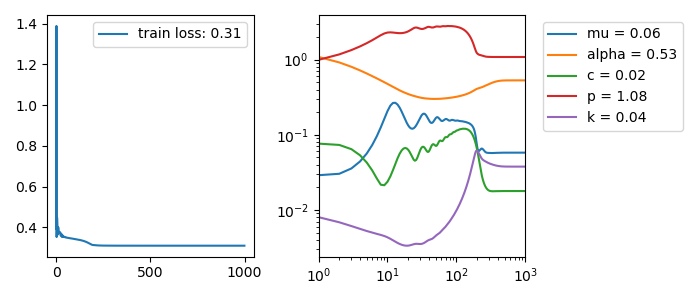

In [60]:
%matplotlib widget
fig, ax = plt.subplots(1,2, figsize=(7,3))
ax[0].plot(train_loss, label=f'train loss: {train_loss[-1]:.2f}')
ax[0].legend()

for param, label in zip([mus, alphas, cs, ps, ks], ['mu', 'alpha', 'c', 'p', 'k']):
    ax[1].plot(param, label=f"{label} = {param[-1]:.2f}")

ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[1].set(
    yscale='log',
    xlim=(1, number_of_epochs),
    xscale='log'
)
plt.tight_layout()

Now we can see how well ETAS performs on the nll period. This is our benchmark performance.

In [52]:
batch = eq.data.Batch.from_list([catalog.val[val_index]])
with torch.no_grad():
    nll = model.nll_loss(batch)
    print(f"NLL: {nll.item()}")

NLL: 0.16189837455749512


Another benchmark to consider is a perisistent forecasts (which of course does not lend itself well to actual forecasts):

In [8]:
seq = copy.deepcopy(catalog.val[val_index])
mask = seq.arrival_times > seq.t_nll_start

lambda_i = (seq.arrival_times < seq.t_nll_start).sum()/(seq.t_nll_start - seq.t_start)
nll_seq = seq.get_subsequence(seq.t_nll_start, seq.t_end)

nll_persistent = 0
for dt in seq.inter_times[:-1]:
    nll_persistent += - torch.log(lambda_i * dt) + lambda_i * dt
    lambda_i = 1/dt

nll_persistent += lambda_i * seq.inter_times[-1] 

nll_persistent = nll_persistent/(seq.t_end - seq.t_nll_start)

print(f"NLL persistent: {nll_persistent.item()}")

NLL persistent: 171.0599822998047


We can now pull a trained recast model and see how it performs on the same sequence. In practive will will want to retrain the model for each sequence and compare the collective performances. 

In [ ]:
def batch_wise_etas_trainer(
    dataset: eq.data.InMemoryDataset,
    number_of_epochs: int = 1000,
    lr: float = 1e-2,
):

    nll = []
    for seq in tqdm.trange(dataset):
        
        # train on the conditioning period, which represent the regional data
        train_seq = copy.deepcopy(seq)
        train_seq.t_nll_start = train_seq.t_start
        train_seq = train_seq.get_subsequence(0, seq.t_nll_start)
        
        batch = eq.data.Batch.from_list([train_seq])
        model = eq.models.ETAS(
            mag_completeness=catalog.metadata["mag_completeness"],
            base_rate_init=10**torch.mean(torch.log(batch.inter_times)), # geometric mean
        )
        
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        
        for _ in number_of_epochs:
            loss = model.nll_loss(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
        # evaluate on the original nll period 
        with torch.no_grad():
            nll.append(model.nll_loss(eq.data.Batch.from_list([seq])).item())
            
    return nll

In [ ]:
etas_val_nll = batch_wise_etas_trainer(catalog.val)
combined_nll = sum(etas_val_nll)

In [19]:
# load trained RECAST model
best_model_path = "/Users/kdascher/Documents/Documents/Berkeley/Projects/DS_discovery/recast/notebooks/kelian/lightning_logs/version_45/checkpoints/epoch=148-step=4470.ckpt" 
model = eq.models.RecurrentTPP.load_from_checkpoint(best_model_path)
model.eval()

# evaluate on the same sequence
recast_val_nll = []
for i in tqdm.trange(len(catalog.val)):
    with torch.no_grad():
        seq = catalog.val[i]
        nll = model.nll_loss(eq.data.Batch.from_list([seq])).item()
        recast_val_nll.append(nll)

100%|██████████| 1000/1000 [00:18<00:00, 54.19it/s]


[(-2.0, 2.0)]

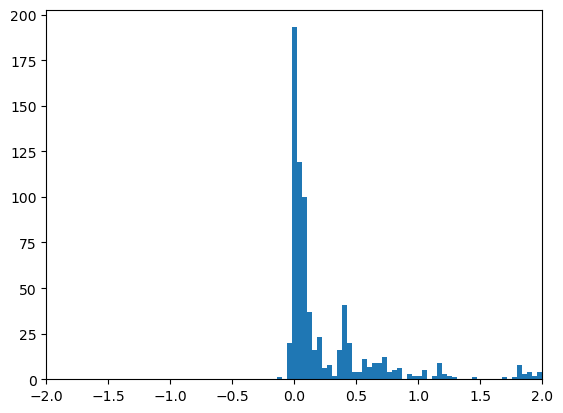

In [58]:
fig, ax = plt.subplots()

extent = 2
ax.hist(np.array(etas_val_nll) - np.array(recast_val_nll), bins=np.linspace(-extent, extent, 100))
ax.set(
    xlim=[-extent,extent]
)



In [90]:
np.mean([e > r for e, r in zip(etas_val_nll, recast_val_nll)])

0.925

Text(0.5, 1.0, 'RECAST vs ETAS on global M6.5+ sequences')

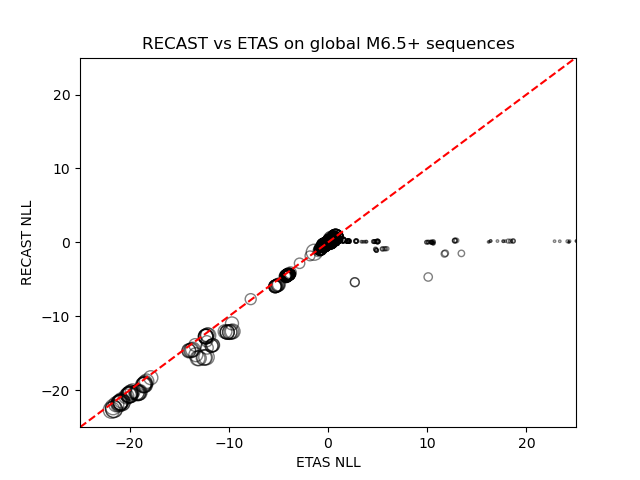

In [106]:
fig, ax = plt.subplots()
plt.scatter(etas_val_nll, recast_val_nll, s=[len(seq.inter_times)/30 for seq in catalog.val], facecolor='none', edgecolor='k', alpha=0.5)
extent = 25
ax.set(
    xlim=[-extent, extent],
    ylim=[-extent, extent]
)
ax.plot([-extent, extent], [-extent, extent], 'r--')

ax.set_xlabel("ETAS NLL")
ax.set_ylabel("RECAST NLL")
ax.set_title("RECAST vs ETAS on global M6.5+ sequences")

In [ ]:
print(np.array([len(seq.inter_times) for seq in catalog.val])[(seq.inter_times > seq.t_nll_start).sum() for seq in catalog.val].mean())

65.20382165605096
1704.3866666666668


In [ ]:
counts_post = [(seq.arrival_times > seq.t_nll_start).sum().item() for seq in catalog.val]
counts_pre = [(seq.arrival_times < seq.t_nll_start).sum().item() for seq in catalog.val]

In [96]:
recast_val_nll[np.array(recast_val_nll).argsort()[0]]

-22.680316925048828

In [99]:
len(np.where(np.array(etas_val_nll) < np.array(recast_val_nll))[0])

75

In [ ]:
%matplotlib widget
number_of_samples = 10
for i in np.where(np.array(etas_val_nll) < np.array(recast_val_nll))[0]:
    eq.visualization.visualize_sequence(catalog.val[i], show_nll=True)

# Take away: 

In this notebook I benchmark the performance of RECAST against ETAS on a per sequence basis by comparing the NLL of the forecasts on a validation interval. The following are inferences dervied from the validation set, not the test set and should be taken with a grain of salt.

### Fair comparison:
It is somewhat difficult to decide how to fairly compare the two models. A major caveat, of course, is that we are using a fairly rudimentary implmentation of the ETAS model. 

Here I was particularly unsure how to calibrate the ETAS model. The approach was to fit the ETAS parameters on the conditioning period and then use the same parameters for the NLL calculation. What should be done in cases where there are nearly no events in the conditioning period? Perhaps there could be some sort of bayesian updating of the parameters? 

### Key results:

(number subject to change) These are results archived on Nov 29, 2025.

Quantitative results:
- 92.5% of sequences have a lower NLL with RECAST than ETAS.

Qualitative results:
- RECAST does not completely miss in the sense that ETAS does. This is reflected in a sharp break in the approximarly 1:1 performance (nll) as seen in the scatter plots.
- The sequences that ETAS slightly outperforms RECAST (n=75) include M9 events. Though I did not exhaustively check whether other sequences include M9 events has better RECAST performance. Similarly, there seem to be some clear swarms in some of auxiliary periods for the sequences that ETAS outperforms RECAST. Again, this set of sequences is an overwhelming minority.
- The sequences that RECAST dramatically outperforms ETAS are clearly characterized by having very few events in the conditioning period. 


### Interpretation:

I will address some key results out of order.

That some sequences are adequately fit by RECAST, but not ETAS -- as evidenced by the sharp break in the 1:1 performance -- seems tightly related to the number of events in the conditioning period. My interpretation is that ETAS is essentially turning off its aftershock triggering mechanism. Then, in the validation interval, expressely selected for containing a sequence, the ETAS model gets very surprised (high NLL) because of the burs of events. 


### Discussion:

In a sense, this benchmarking configuration gives an unfair advantage to RECAST. The training set used for RECAST is tailored to the contents of the validation set. In a sense, RECAST expects to be used in sequences containing large events. RECAST is conditioned on periods of large mainshocks. In contrast, ETAS is trained on the local catalog and is explicitely not conditioned on the presence of large events. 

It is difficult to say what is "fair" here. That we can design a training procedure that conditions on the ultimate use case is a feature of the deep learning approach. That said, practitioners will also imbue ETAS models with tweaks to account for the large-event use case. These tweaks include: essentially driving mu (the background seismicity) to zero, fixing alpha, and creating priors on the parameters based on other large earthquakes analogs (e.g. event that share similar geological context).

Finally, these models are fundamentally different. I understand RECAST to be more like markov process, or an ODE. Observations stream in and the RNN has update rules that change a hidden state. ETAS has a single set of parameters that is used to generate the conditional intensity function. I get the sense that these NLL comparisons are not entirely fair because of this difference. A fairer comparison might be to define a comparable set of updates to the ETAS parameters and see how the models compare. The most crude version of this would be to update ETAS parameters with each event. In practice, ETAS models are updated sporadically (e.g. every day or week) either on a schedule or based on expert judgement. This recursive strategy is essentially hardcoded into RECAST.

A pleasant accident of the benchmarking exercise is that, due to the odd training procedure of the ETAS model, I computed the NLL on each sequence. This allowed for a substantially more detailed analysis of the performance of the models. Combining the NLL can have two effects: 1) a single sequence can have an outsized effect on the total NLL (this is definiely the case in two varying degree of severity with ETAS), 2) the NLL is a function of the number of events in the sequence this restults in more weight more more vigoerous sequences. The latter effect is arguably not a bad thing, but should be kept in mind. Note that in this comparison it is actually the sequences that were more sparse that had an outsized effect on the total NLL because the ETAS model failed to fit the background seismicity correctly (so I interpret). 

One issue that might have come up in interpreting the relative performances is potential artefacts from the random sampling in the creation of the training and valiations sets. I do not think this is important here considering the outsized effect of the previous factors I mentioned. Still, it is worth noting some quicks here: there are multiple quasi-duplicate sequenceses in the training and validation sets where the NLL interval brackets the same sequence multiple times. I don't think this is expericitly causing biases because the sampling is IID and therefore the dataset remains representative.

#### Potential improvements to ETAS:
- Update ETAS parameters with each event or on a schedule. Though this would be computationally demanding unless I figure out how to do it efficiently.
- Create a prior on the parameters based on other large earthquakes analogs.
- Consider fixing some parameters. 

#### Potential improvements to RECAST:
- Use augmented data to train RECAST.
- Finetune of the auxiliary period of the local catalog.

#### Potential improvements to the benchmarking configuration:
- Check that the conclusions hold for the test set.
- Implement the improvement to the ETAS model outlined above.
- Save a consistent val/test set.
- Another experiement that compared the forecasting performance (e.g. 2 weeks), in particular after the larger events.

### Conclusion:

As of this date, this notebook presents a benchmark of RECAST against ETAS on a per sequence basis. The results are encouraging for RECAST demonstraing out of the box performance that substantially outperforms ETAS. It seems important that RECAST is never completely wrong (as described in the qualitative results section). The suggests a novel use case for major earthquakes that hit regions with sparse prior seismicity (e.g. Cascadia). One asteresk is ETAS performed relatively well in sequences that contained extreme (out of sample) events. 

Another landmark result is that RECAST is performing well on a standard catalog and explicitely used to forecast felt events (M4.5+). Amusingly, it shines where the data is sparse.

The gold standard would be to compare RECASTs performance agains an OAF model. In principle this is possible, but would require some work to implement and some direct collaboration with the OAF team.
